# **Análise Exploratória de Dados (EDA)**

EDA é o processo de investigar um dataset antes de qualquer modelagem ou conclusão.
Com ele podermos verificar o que contém no Dataset, como os dados estão organizados, o que está errado e quais padrões já aparecem.



*   Item da lista
*   Item da lista



O **Dataset Iris** é um conjunto de dados introduzido pelo biólogo e estatístico Ronald Fisher. Ele contém 150 amostras de flores de três espécies de íris (50 amostras por espécie) e é composto por 5 variáveis.

**Primeiro**, precisamos importar as bibliotécas que precisamos usar e também baixar uma variável os dados, que nesse caso está no GitHub.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando o dataset do Iris
url = 'https://raw.githubusercontent.com/dvbcknd/SENAI_POS_TECNICO/refs/heads/main/Estatistica/iris.csv'
df = pd.read_csv(url)

Para termos noção das dimenções do Dataset, usamos a função **.sahpe[]** do Pandas, que trás para a gente as dimenções **X (linha) e Y (colunas)**, acessamos usando os valores **0 e 1** respectivamente.

In [49]:
# Dimensões do dataset — quantas linhas e colunas
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

Linhas: 150
Colunas: 5


## O Dicionário está catalogado em **05 colunas** que são elas:

- **sepal_length** (Comprimento da Sépala): Medida do comprimento da sépala da flor (em centímetros).
- **sepal_width** (Largura da Sépala): Medida da largura da sépala da flor (em centímetros).
- **petal_length** (Comprimento da Pétala ): Medida do comprimento da pétala da flor (em centímetros).
- **petal_width** (Largura da Pétala): Medida da largura da pétala da flor (em centímetros).
- **species** (Espécie): Variável alvo (target) que indica a espécie da flor. As três classes possíveis são:
  - Iris-setosa
  - Iris-versicolor
  - Iris-virginica

**Nota:**  Sépola é a estrutura externa, na maioria das vezes, verde, cuja função é a proteção da flor ainda em botão. Fica localizada nas bases das pétalas. São as folhas verdes que ficam abaxido da flor, quando ela está aberta.

Para exibir as colunas chamamos a propriedade **.columns** do Pandas e transformandos elas em um item de lista com **.tolist()**, e imprimimos tudo usando o **print()**

In [50]:
# Nome das colunas
print(df.columns.tolist())

['sepal.length', 'sepal.width', 'petal.length', 'petal.width', 'variety']


Para sabermos os tipos das colunas usamos a função nativa do Pandas, **.info()**, que trás para a gente os dados detalhados da tabela.

Os tipos de dados podem ser:
 -  int64 = número inteiro
 - float64 = número decimal
 - object = texto

In [51]:
# Tipos de dados de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [52]:
# Primeiras linhas e uma visão geral dos dados
df.head(10)

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
5,5.4,3.9,1.7,0.4,Setosa
6,4.6,3.4,1.4,0.3,Setosa
7,5.0,3.4,1.5,0.2,Setosa
8,4.4,2.9,1.4,0.2,Setosa
9,4.9,3.1,1.5,0.1,Setosa


## Estatísticas descritivas:

As estatísticas descritivas dão uma visão geral de cada variável numérica, aqui da para perceber se os valores fazem sentido, se existem números impossíveis e qual é o comportamento típico de cada coluna.


Usamos a função **.describe()** do Pandas, ela nos trás os seguintes dados:

 - count = total de valores
 - mean = média
 - std = desvio padrão
 - min = mínimo
 - 25% = Q1
 - 50% = mediana
 - 75% = Q3
 - max = máximo

In [53]:
# Resumo estatístico de todas as colunas numéricas
df.describe()

,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [54]:
# Medidas de dispersão
resumo = pd.DataFrame({
    'Amplitude': df.max(numeric_only=True) - df.min(numeric_only=True),
    'Variância': df.var(numeric_only=True).round(2),
    'Desvio Padrão': df.std(numeric_only=True).round(2)
})

resumo

,Amplitude,Variância,Desvio Padrão
sepal.length,3.6,0.69,0.83
sepal.width,2.4,0.19,0.44
petal.length,5.9,3.12,1.77
petal.width,2.4,0.58,0.76


## Verificando se a valores ausentes:

Dados reais podem conter valores faltando. **Apesar desse dataset não ter valores faltando**, como é possível verificar no código abaixo.  
Um modelo treinado com valores ausentes sem tratamento pode aprender padrões errados ou simplesmente travar. É preciso saber onde estão os valores ausentes, quanto representam do total e o que fazer com eles.



In [55]:
# Contagem de valores ausentes por coluna
ausentes = df.isnull().sum()

# Percentual de valores ausentes
percentual = (df.isnull().sum() / len(df) * 100).round(2)

# Juntando as duas informações
resumo_ausentes = pd.DataFrame({
    'Valores Ausentes': ausentes,
    'Percentual (%)': percentual
})

# Mostrando as colunas
resumo_ausentes[resumo_ausentes['Valores Ausentes'] >= 0]

,Valores Ausentes,Percentual (%)
sepal.length,0,0.0
sepal.width,0,0.0
petal.length,0,0.0
petal.width,0,0.0
variety,0,0.0


Esse dataset não tem dados faltando, então não precisa ser tratado em relação a isso.

## Verificar duplicatas

Registros duplicados fazem o modelo contar a mesma informação duas vezes, distorcendo os padrões aprendidos.  


A função **.duplicated()** do Pandas nos trás esses dados, que somamos com a função **.sum()**.

Para excluir os dados usamos a função **.drop_duplicates()**.

In [56]:
print(f'Registros duplicados: {df.duplicated().sum()}')

df = df.drop_duplicates()
print(f'Registros duplicados: {df.duplicated().sum()}')

Registros duplicados: 1
Registros duplicados: 0


## Analisar a distribuição das variáveis

Entender como cada variável se distribui revela se os dados são simétricos ou assimétricos, se há concentração em algum valor e se a variável tem comportamento esperado para o contexto. Muitos algoritmos de machine learning assumem que os dados seguem uma distribuição normal

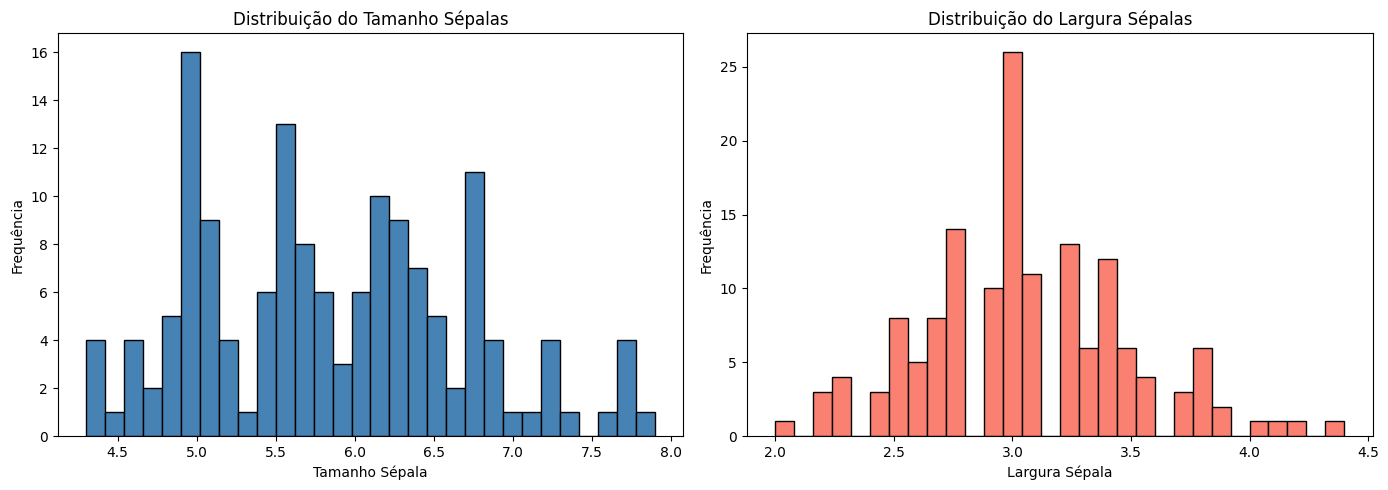

In [57]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Histograma da Tamanho Sépala
axs[0].hist(df['sepal.length'], bins=30, color='steelblue', edgecolor='black')
axs[0].set_title('Distribuição do Tamanho Sépalas')
axs[0].set_xlabel('Tamanho Sépala')
axs[0].set_ylabel('Frequência')

# Histograma da Largura da Sépala
axs[1].hist(df['sepal.width'], bins=30, color='salmon', edgecolor='black')
axs[1].set_title('Distribuição do Largura Sépalas')
axs[1].set_xlabel('Largura Sépala')
axs[1].set_ylabel('Frequência')


plt.tight_layout()
plt.show()

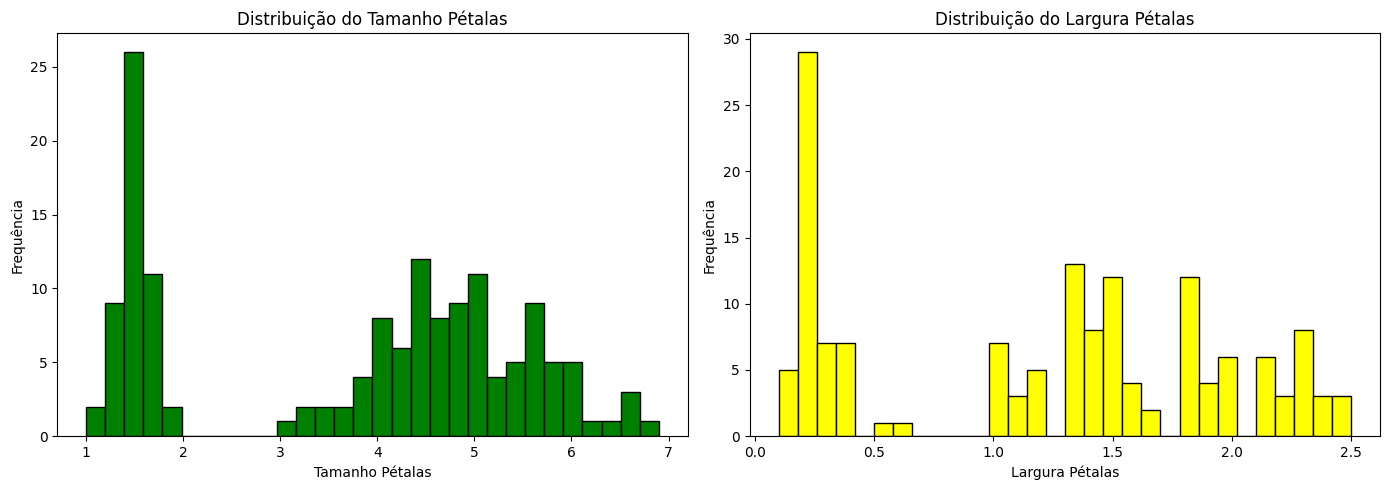

In [58]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Histograma da Tamanho Sépala
axs[0].hist(df['petal.length'], bins=30, color='green', edgecolor='black')
axs[0].set_title('Distribuição do Tamanho Pétalas')
axs[0].set_xlabel('Tamanho Pétalas')
axs[0].set_ylabel('Frequência')

# Histograma da Largura da Sépala
axs[1].hist(df['petal.width'], bins=30, color='yellow', edgecolor='black')
axs[1].set_title('Distribuição do Largura Pétalas')
axs[1].set_xlabel('Largura Pétalas')
axs[1].set_ylabel('Frequência')


plt.tight_layout()
plt.show()

## Análise de Outliers e Dispersão (Boxplots)

O gráfico abaixo permite identificar anomalias (outliers) na largura das sépalas e demonstra visualmente como o tamanho das pétalas isola perfeitamente a espécie Setosa das demais.

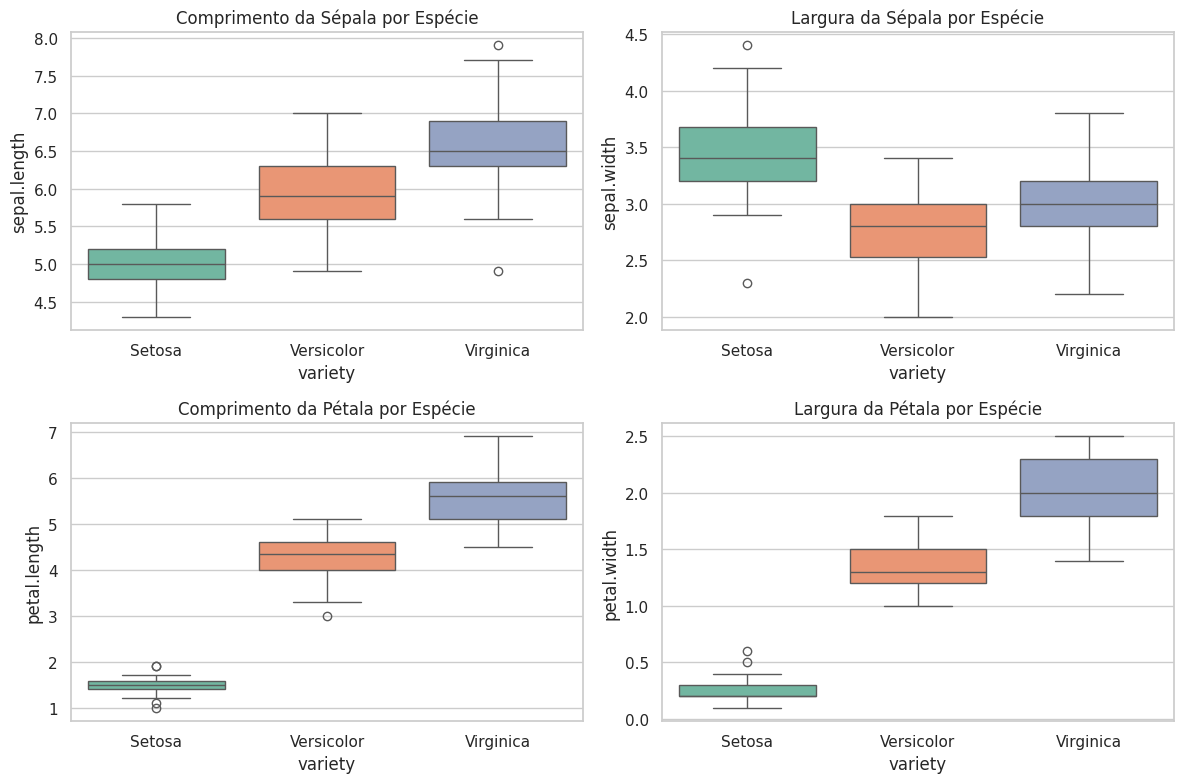

In [65]:
# Configura o estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Código atualizado com hue="variety" e legend=False para eliminar o aviso
plt.subplot(2, 2, 1)
sns.boxplot(x="variety", y="sepal.length", data=df, hue="variety", palette="Set2", legend=False)
plt.title("Comprimento da Sépala por Espécie")

plt.subplot(2, 2, 2)
sns.boxplot(x="variety", y="sepal.width", data=df, hue="variety", palette="Set2", legend=False)
plt.title("Largura da Sépala por Espécie")

plt.subplot(2, 2, 3)
sns.boxplot(x="variety", y="petal.length", data=df, hue="variety", palette="Set2", legend=False)
plt.title("Comprimento da Pétala por Espécie")

plt.subplot(2, 2, 4)
sns.boxplot(x="variety", y="petal.width", data=df, hue="variety", palette="Set2", legend=False)
plt.title("Largura da Pétala por Espécie")

# Ajusta o espaçamento para não sobrepor os títulos
plt.tight_layout()
plt.show()

## Matriz de Correlação Linear (Heatmap)

#### Descrição:
Nesta etapa, calculamos o Coeficiente de Correlação de Pearson entre as quatro variáveis numéricas do dataset. O objetivo é identificar o grau de associação linear entre os atributos das flores e entender quais características se movem juntas.

#### Conclusões Estatísticas:
* **Forte Correlação Positiva:** O comprimento da pétala (`petal.length`) e a largura da pétala (`petal.width`) possuem uma correlação fortíssima (~0.96), indicando que são variáveis altamente dependentes.
* **Independência/Correlação Negativa:** A largura da sépala (`sepal.width`) caminha no sentido oposto das medidas da pétala, mostrando uma correlação negativa moderada.

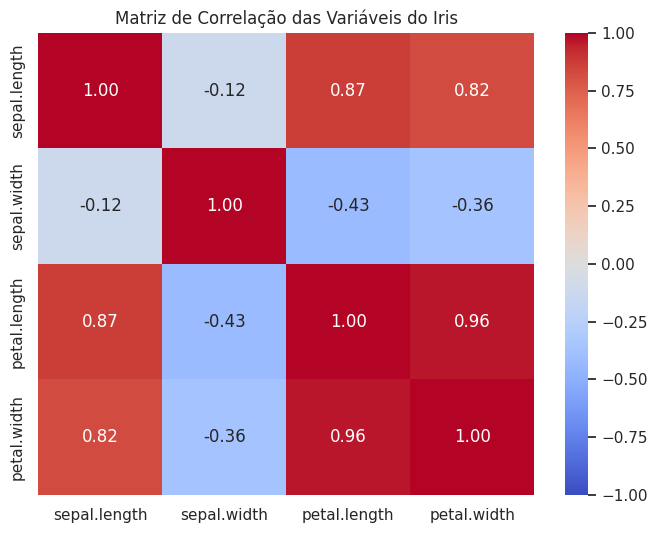

In [67]:

# 1. Seleciona apenas as colunas numéricas do seu dataframe
colunas_numericas = df[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']]

# 2. Calcula a matriz de correlação de Pearson
matriz_corr = colunas_numericas.corr()

# 3. Configura o tamanho do gráfico
plt.figure(figsize=(8, 6))

# 4. Desenha o mapa de calor (Heatmap)
sns.heatmap(
    matriz_corr,
    annot=True,          # Mostra os números dentro dos quadrados
    cmap='coolwarm',     # Cor: azul para negativo, vermelho para positivo
    fmt=".2f",           # Arredonda para 2 casas decimais
    vmin=-1, vmax=1      # Força a escala a ir de -1 a 1
)

plt.title('Matriz de Correlação das Variáveis do Iris')
plt.show()

# Conclusão Final da Análise Exploratória (EDA)

Após investigar o comportamento das variáveis, suas distribuições e as relações de correlação, chegamos às seguintes conclusões estatísticas e de negócio sobre o Dataset Iris:

### 1. Viabilidade de Classificação (O problema pode ser resolvido?)
Sim, o conjunto de dados fornece informações riquíssimas e altamente capazes de discriminar as três espécies de flores. O fato de o dataset ser **perfeitamente balanceado** (50 amostras por classe) garante que qualquer análise ou modelo futuro não sofrerá com vieses de proporção.

### 2. O papel crítico das Pétalas (Poder Preditivo)
A análise visual (Boxplots e Histogramas) e a análise numérica (Matriz de Correlação) confirmam unanimemente que **as características das pétalas (`petal.length` e `petal.width`) são os melhores preditores do dataset**. Elas possuem uma correlação positiva quase perfeita (~0.96) e mostram uma separação clara entre os grupos nos histogramas (comportamento bimodal).

### 3. Comportamento das Espécies
* **Iris Setosa:** É o grupo estatisticamente isolado. Ela possui pétalas significativamente menores que as demais espécies, tornando sua identificação 100% precisa por meio de regras simples de corte linear (ex: se `petal.length` < 2 cm, é Setosa).
* **Iris Versicolor e Iris Virginica:** Apresentam um desafio estatístico maior. Suas características físicas se sobrepõem, especialmente nas medidas das sépalas. A *Virginica* tende a ser maior que a *Versicolor*, mas a fronteira entre elas não é perfeitamente linear, exigindo algoritmos de Machine Learning (como Árvores de Decisão ou KNN) para uma separação precisa.

### 4. Qualidade dos Dados (Outliers)
Identificamos a presença de *outliers* pontuais na variável de largura da sépala (`sepal.width`), principalmente na espécie *Setosa*. No entanto, essas anomalias são variações biológicas naturais e de baixa magnitude, não representando ruídos ou erros de digitação que exijam a exclusão dos dados.

